In [35]:
# download data of AAPL's stock price from yfinance in 4 mounths

!pip install yfinance
import yfinance as yf
import pandas as pd

data = yf.download("AAPL", start="2026-01-01", end="2026-04-13")
print(data.head(7))
#print(data.head())      first 5 line will be printed by defult

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-01-02  270.756653  277.580254  268.748522  272.005484  37838100
2026-01-05  267.010162  271.256189  265.891214  270.387007  45647200
2026-01-06  262.114716  267.299866  261.874950  266.750392  52352100
2026-01-07  260.086609  263.433483  259.567106  262.953951  48309800
2026-01-08  258.797852  259.047618  255.460962  256.779720  50419300
2026-01-09  259.127533  259.966744  255.980484  258.837796  39997000
2026-01-12  260.006714  261.055720  256.559927  258.917736  45263800


In [34]:
# cleasing missing values

df = data[['Close']] #only keep the close price colume

print("\nMissing values: ")
print(df.isnull().sum())

df = df.dropna()  #function of cleaning these missing values

print("\nCleaned Data: ")
print(df.head())


Missing values: 
Price  Ticker
Close  AAPL      0
dtype: int64

Cleaned Data: 
Price            Close
Ticker            AAPL
Date                  
2026-01-02  270.756653
2026-01-05  267.010162
2026-01-06  262.114716
2026-01-07  260.086609
2026-01-08  258.797852


In [36]:
#caculate key indexes

df['Return'] = df['Close'].pct_change()  #add a new colume in dataframe as a varible colume
df = df.dropna()    #the ()is improtant otherwise this'd be the dropana method itself,not a data sheet 

print("\nData with Returns: ")
print(df.head(5))

mean_return = df['Return'].mean()
volatility = df['Return'].std()
print("\nStatistics")
print("Average Return: ",mean_return )
print("Volatility: ", volatility)


Data with Returns: 
Price            Close    Return
Ticker            AAPL          
Date                            
2026-01-05  267.010162 -0.013837
2026-01-06  262.114716 -0.018334
2026-01-07  260.086609 -0.007737
2026-01-08  258.797852 -0.004955
2026-01-09  259.127533  0.001274

Statistics
Average Return:  -0.00045765825407911934
Volatility:  0.015568963191149513


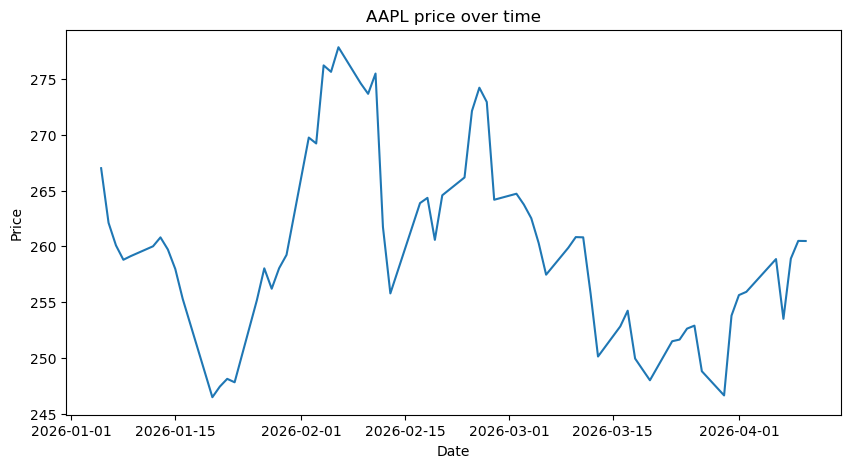

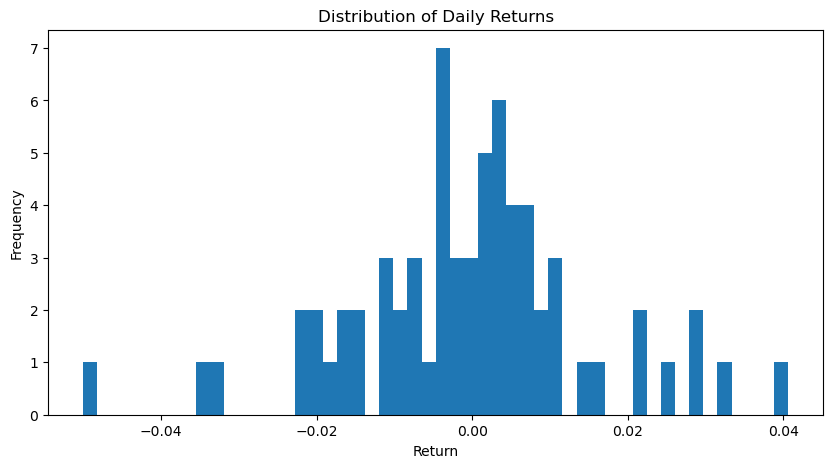

In [39]:
#Visualization
import matplotlib.pyplot as plt

#Price Trend
plt.figure(figsize=(10,5))
plt.plot(df['Close'])   #Broken line
plt.title("AAPL price over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

#Return distribution(histogram)
plt.figure(figsize=(10,5))
plt.hist(df['Return'], bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

[*********************100%***********************]  3 of 3 completed



Correlation Matrix: 
Ticker      AAPL      MSFT      TSLA
Ticker                              
AAPL    1.000000  0.113558  0.225935
MSFT    0.113558  1.000000  0.328514
TSLA    0.225935  0.328514  1.000000


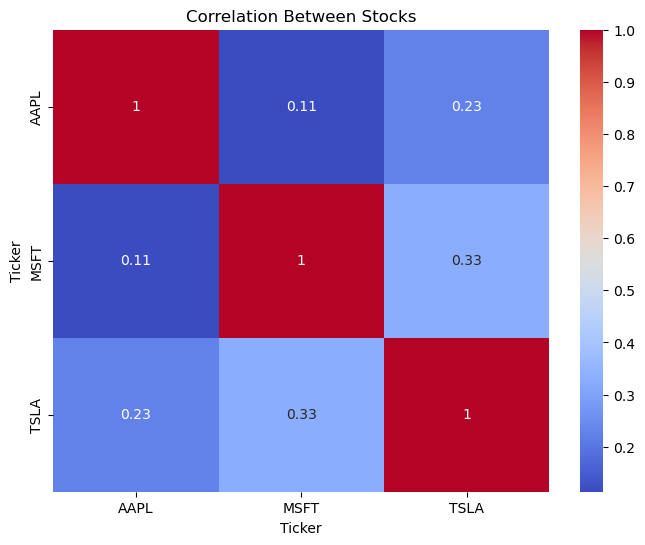

In [43]:
#Multi asset analysis
#plt, sns belongs to matplotlib,plt is for basic canvas incluidng axes, title and broken line etc. 
#and sns is for more completed statics diagram such as heatmap.

import seaborn as sns
data_multi = yf.download(["AAPL", "MSFT", "TSLA"], start="2026-01-01", end="2026-04-13")['Close']
correlation = data_multi.pct_change().dropna().corr()

print("\nCorrelation Matrix: ")
print(correlation)

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")  #annot=true:with figrues in the heatmap
plt.title("Correlation Between Stocks")
plt.show()